# Analysis & Visualization — Model Behavior

## Objective

Visualize how different models perform in predicting next-day energy demand.

We focus on:

- Where models succeed and fail
- Differences between linear and nonlinear models
- How weather impacts prediction quality

---

## Models

- Linear Regression
- Random Forest
- Gradient Boosting

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parents[0]))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from configs.config import *

plt.style.use("default")

In [2]:
file_path = PROCESSED_DATA_DIR / "aep_features.csv"

df_model = pd.read_csv(file_path)
df_model["Datetime"] = pd.to_datetime(df_model["Datetime"])

In [3]:
features = [
    "load_lag_1",
    "load_lag_2",
    "load_lag_3",
    "load_lag_7",
    "day_of_week",
    "is_weekend",
    "temp_mean"
]

X = df_model[features]
y = df_model["target"]

split_idx = int(len(df_model) * 0.8)

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

dates_test = df_model["Datetime"].iloc[split_idx:]

In [4]:
lr = LinearRegression().fit(X_train, y_train)

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
).fit(X_train, y_train)

gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    random_state=RANDOM_STATE
).fit(X_train, y_train)

In [5]:
pred_lr = lr.predict(X_test)
pred_rf = rf.predict(X_test)
pred_gb = gb.predict(X_test)

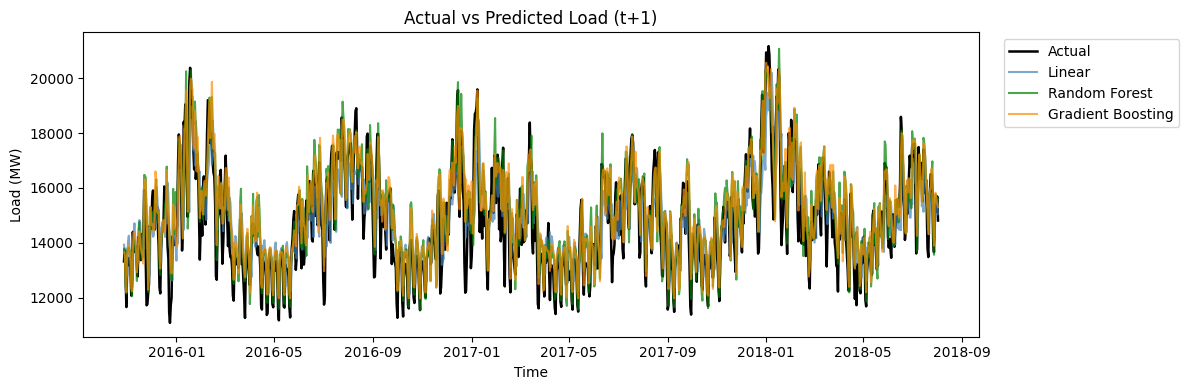

In [6]:
plt.figure(figsize=(12, 4))

plt.plot(dates_test, y_test, color="black", linewidth=1.8, label="Actual")

plt.plot(dates_test, pred_lr, color="steelblue", alpha=0.7, label="Linear")
plt.plot(dates_test, pred_rf, color="green", alpha=0.7, label="Random Forest")
plt.plot(dates_test, pred_gb, color="darkorange", alpha=0.7, label="Gradient Boosting")

plt.title("Actual vs Predicted Load (t+1)")
plt.xlabel("Time")
plt.ylabel("Load (MW)")

plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

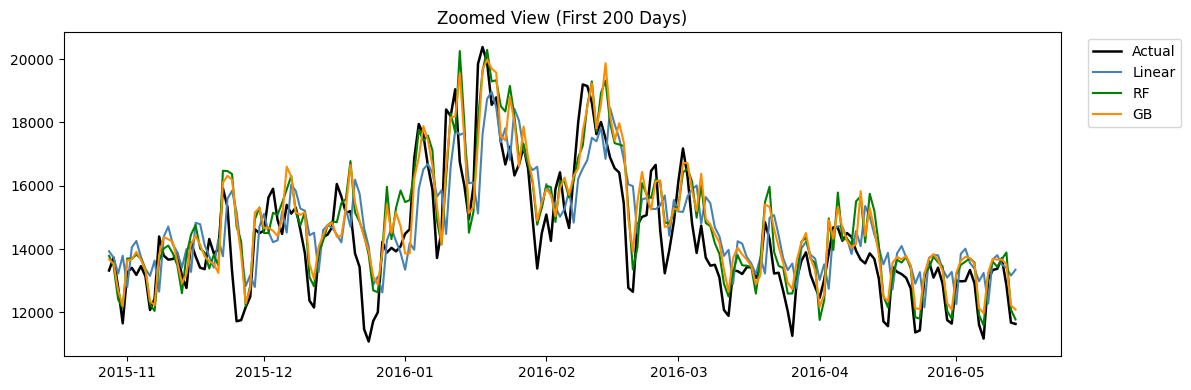

In [7]:
zoom = 200  # first 200 days of test

plt.figure(figsize=(12, 4))

plt.plot(dates_test[:zoom], y_test[:zoom], color="black", linewidth=1.8, label="Actual")

plt.plot(dates_test[:zoom], pred_lr[:zoom], color="steelblue", label="Linear")
plt.plot(dates_test[:zoom], pred_rf[:zoom], color="green", label="RF")
plt.plot(dates_test[:zoom], pred_gb[:zoom], color="darkorange", label="GB")

plt.title("Zoomed View (First 200 Days)")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

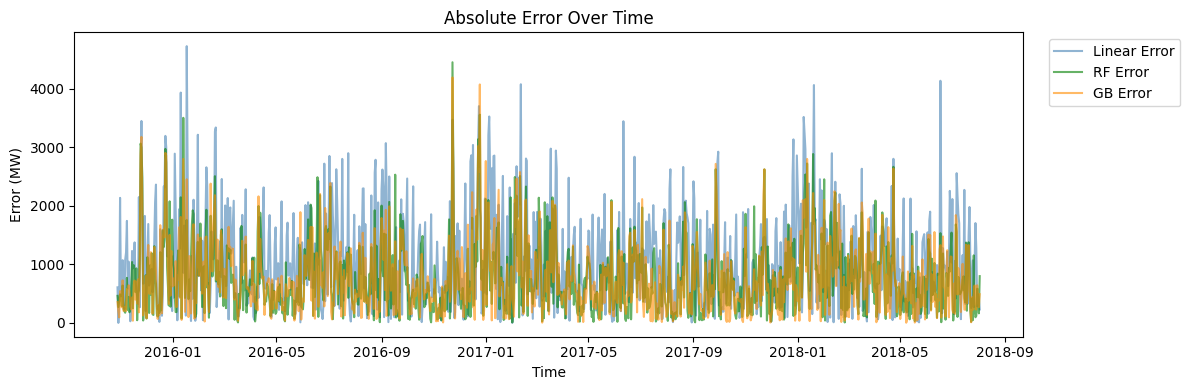

In [8]:
error_lr = np.abs(y_test - pred_lr)
error_rf = np.abs(y_test - pred_rf)
error_gb = np.abs(y_test - pred_gb)

plt.figure(figsize=(12, 4))

plt.plot(dates_test, error_lr, color="steelblue", alpha=0.6, label="Linear Error")
plt.plot(dates_test, error_rf, color="green", alpha=0.6, label="RF Error")
plt.plot(dates_test, error_gb, color="darkorange", alpha=0.6, label="GB Error")

plt.title("Absolute Error Over Time")
plt.xlabel("Time")
plt.ylabel("Error (MW)")

plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

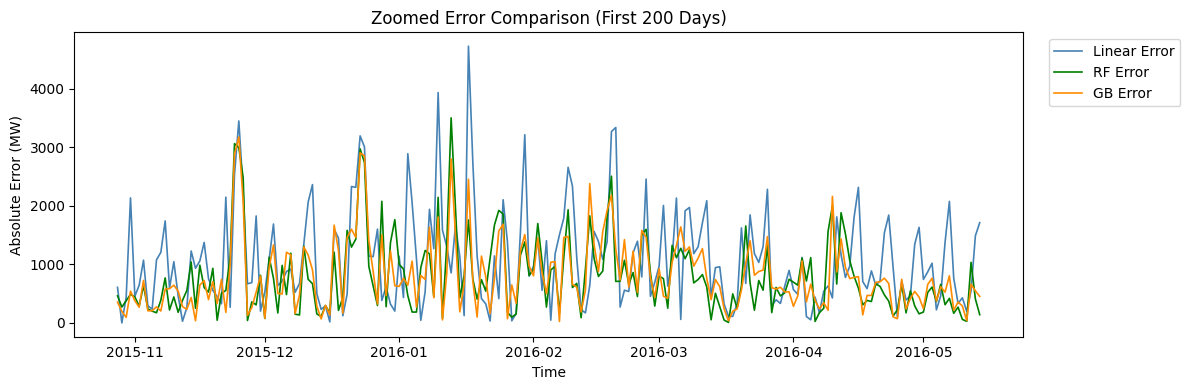

In [9]:
zoom = 200  # same zoom window as before

plt.figure(figsize=(12, 4))

plt.plot(dates_test[:zoom], error_lr[:zoom],
         color="steelblue", linewidth=1.2, label="Linear Error")

plt.plot(dates_test[:zoom], error_rf[:zoom],
         color="green", linewidth=1.2, label="RF Error")

plt.plot(dates_test[:zoom], error_gb[:zoom],
         color="darkorange", linewidth=1.2, label="GB Error")

plt.title("Zoomed Error Comparison (First 200 Days)")
plt.xlabel("Time")
plt.ylabel("Absolute Error (MW)")

plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

## Diagnostic Analysis — Why Didn’t the Linear Model Improve?

We investigate whether the weak improvement of the linear model with temperature is due to:

- a nonlinear temperature-demand relationship
- systematic residual structure across temperature
- poor representation of temperature using only a single linear term

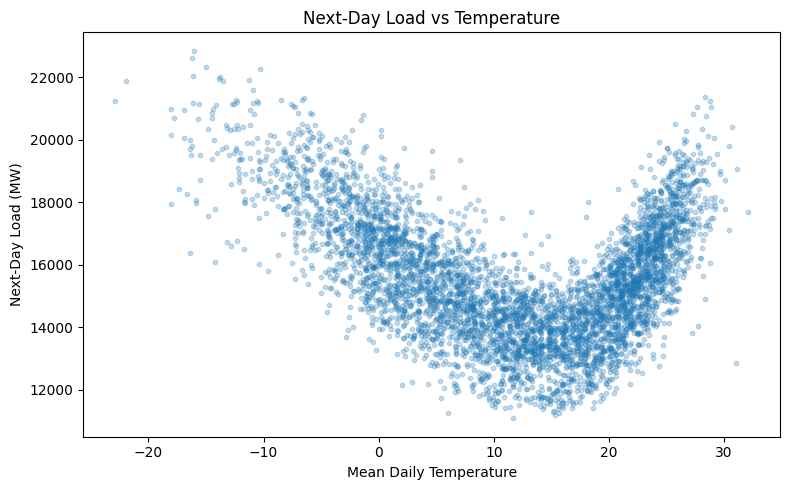

In [10]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df_model["temp_mean"],
    df_model["target"],
    alpha=0.25,
    s=10
)

plt.title("Next-Day Load vs Temperature")
plt.xlabel("Mean Daily Temperature")
plt.ylabel("Next-Day Load (MW)")
plt.tight_layout()
plt.show()

Look for whether the temperature-demand relationship appears roughly linear or curved.

If both cold and hot temperatures correspond to higher load, the relationship is likely nonlinear.

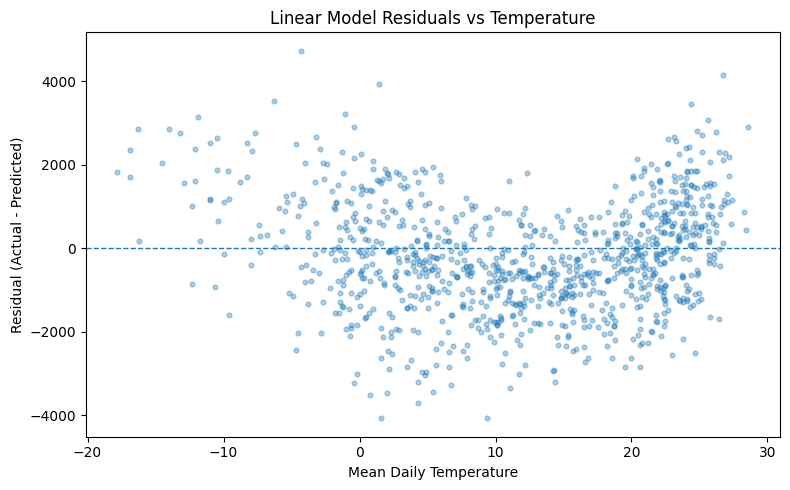

In [11]:
residual_lr = y_test - pred_lr

plt.figure(figsize=(8, 5))

plt.scatter(
    X_test["temp_mean"],
    residual_lr,
    alpha=0.35,
    s=12
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Linear Model Residuals vs Temperature")
plt.xlabel("Mean Daily Temperature")
plt.ylabel("Residual (Actual - Predicted)")
plt.tight_layout()
plt.show()

Interpretation guide:

- residuals near zero across all temperatures → linear temperature term may be sufficient
- systematic curvature or clustering at cold/hot extremes → linear model is missing nonlinear structure

In [12]:
diagnostic_df = pd.DataFrame({
    "Datetime": dates_test.values,
    "temp_mean": X_test["temp_mean"].values,
    "actual": y_test.values,
    "pred_lr": pred_lr,
    "pred_rf": pred_rf,
    "pred_gb": pred_gb
})

diagnostic_df["abs_error_lr"] = np.abs(diagnostic_df["actual"] - diagnostic_df["pred_lr"])
diagnostic_df["abs_error_rf"] = np.abs(diagnostic_df["actual"] - diagnostic_df["pred_rf"])
diagnostic_df["abs_error_gb"] = np.abs(diagnostic_df["actual"] - diagnostic_df["pred_gb"])

In [13]:
diagnostic_df["temp_bin"] = pd.cut(
    diagnostic_df["temp_mean"],
    bins=[-20, 0, 10, 20, 30, 50],
    labels=["<0", "0-10", "10-20", "20-30", ">30"]
)

diagnostic_df[["temp_mean", "temp_bin"]].head()

,temp_mean,temp_bin
0,14.1,10-20
1,9.6,0-10
2,8.1,0-10
3,9.6,0-10
4,13.6,10-20


In [14]:
error_by_bin = diagnostic_df.groupby("temp_bin", observed=False)[
    ["abs_error_lr", "abs_error_rf", "abs_error_gb"]
].mean()

error_by_bin

,abs_error_lr,abs_error_rf,abs_error_gb
temp_bin,,,
<0,1252.007105,990.045481,919.021854
0-10,1075.841506,874.222159,886.012842
10-20,996.677847,569.054579,628.008052
20-30,1021.200561,743.178311,695.866496
>30,NaN,NaN,NaN


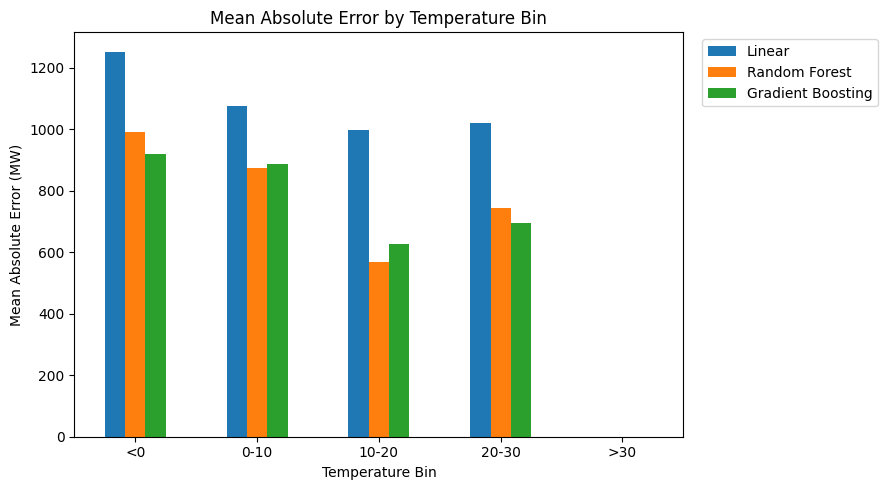

In [15]:
error_by_bin.plot(kind="bar", figsize=(9, 5))

plt.title("Mean Absolute Error by Temperature Bin")
plt.xlabel("Temperature Bin")
plt.ylabel("Mean Absolute Error (MW)")
plt.xticks(rotation=0)
plt.legend(["Linear", "Random Forest", "Gradient Boosting"],
           loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()